In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported! ✅")

Libraries imported! ✅


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shantanudhakadd/bank-customer-churn-prediction/Churn_Modelling.csv


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shantanudhakadd/bank-customer-churn-prediction/Churn_Modelling.csv


In [5]:
df = pd.read_csv('/kaggle/input/datasets/shantanudhakadd/bank-customer-churn-prediction/Churn_Modelling.csv')
print(df.shape)
print(df.head())

(10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4

In [6]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])
X = df.drop('Exited', axis=1)
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Data ready! ✅")

Data ready! ✅


In [7]:
# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred) * 100

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred) * 100

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred) * 100

print("Logistic Regression:", round(lr_acc, 2), "%")
print("Random Forest:", round(rf_acc, 2), "%")
print("Gradient Boosting:", round(gb_acc, 2), "%")

Logistic Regression: 81.55 %
Random Forest: 86.45 %
Gradient Boosting: 86.6 %


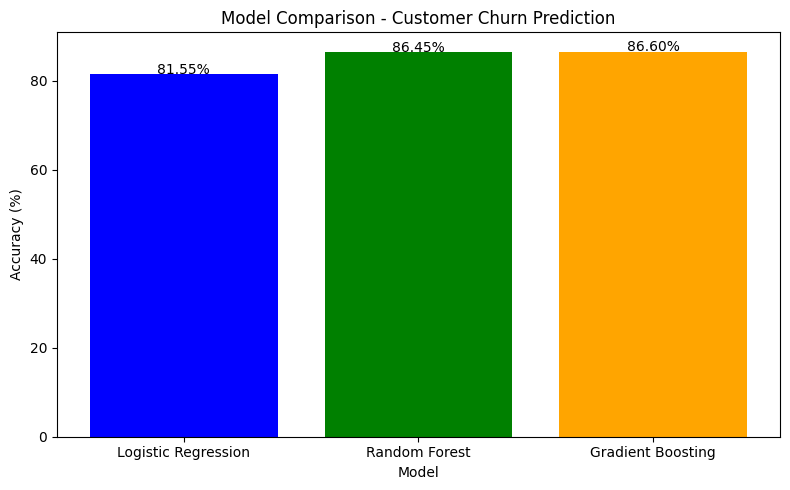

In [8]:
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
accuracies = [lr_acc, rf_acc, gb_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.title('Model Comparison - Customer Churn Prediction')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center')
plt.tight_layout()
plt.show()

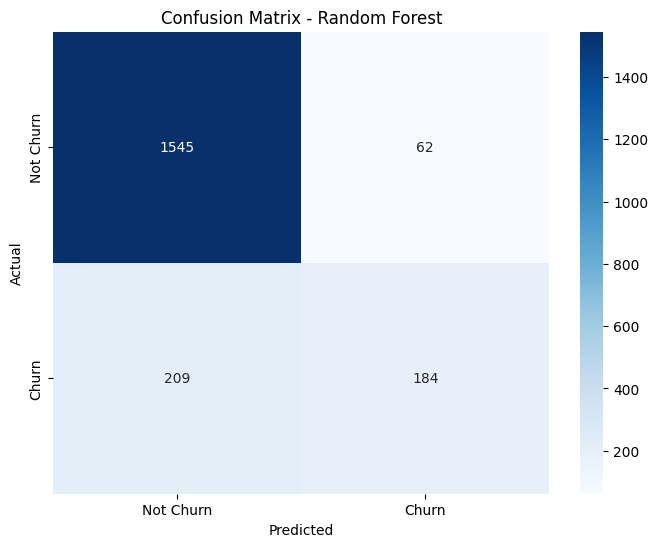

In [9]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

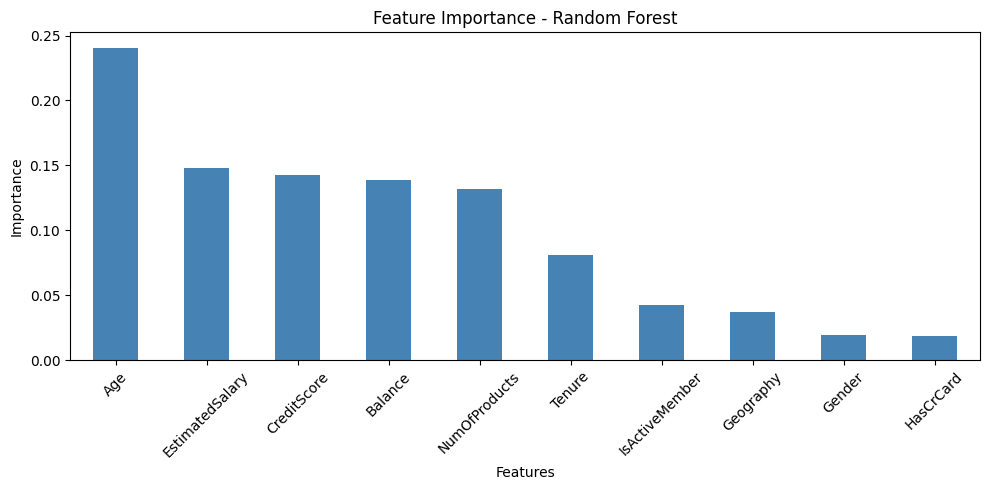

In [10]:
feat_imp = pd.Series(rf.feature_importances_, 
                     index=df.drop('Exited', axis=1).columns)
feat_imp.sort_values(ascending=False).plot(kind='bar', 
                                           figsize=(10, 5),
                                           color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()